   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.5/400.5 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.3/106.3 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.0 MB/s eta 0:00:00
File found: True
Shape: (51, 9)
                 Arc  Start onChapter  TotalChapters  TotalPages Manga%  \
0   Romance Dawn Arc                1              7         178   0.9%   
1    Orange Town Arc                8             14         273   1.4%   
2  Syrup Village Arc               22             20         396   2.0%   
3        Baratie Arc               42             27         514   2.6%   
4    Arlong Park Arc               69             27         514   2.6%   

   Start onEpisode  TotalEpisodes  TotalM

100%|██████████| 13/13 [00:00<00:00, 81.31it/s]


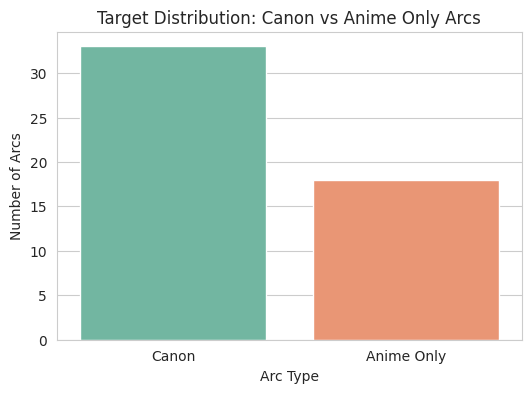

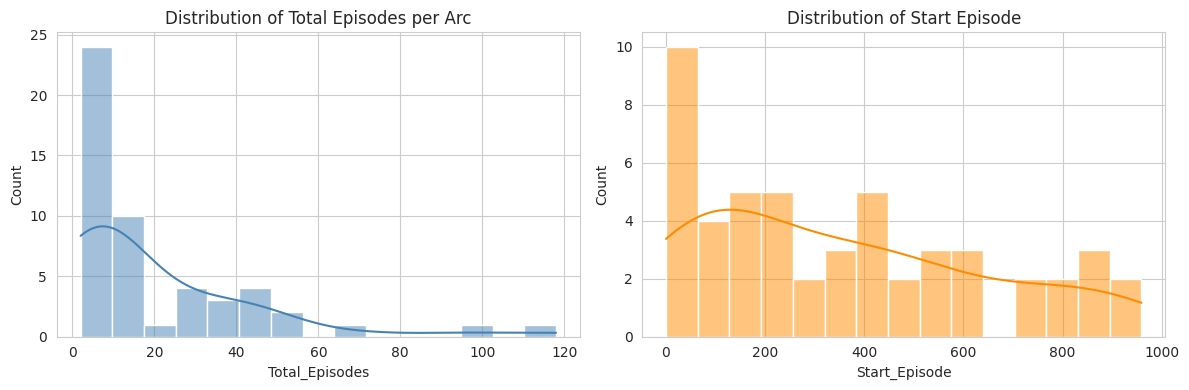

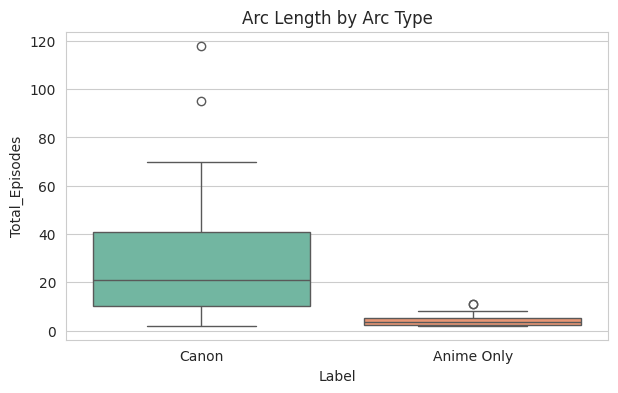

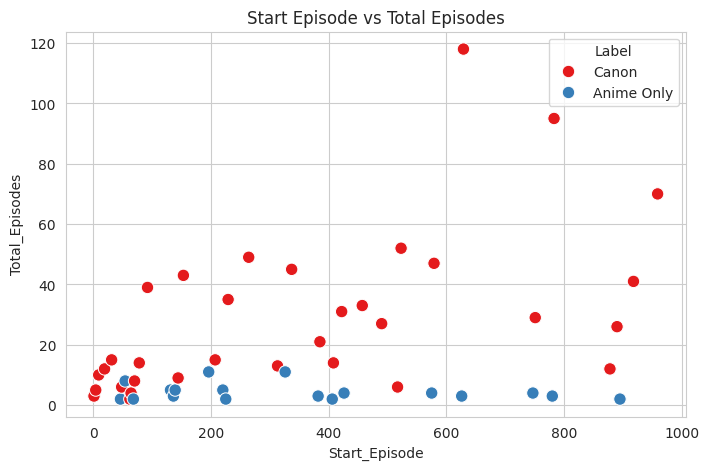

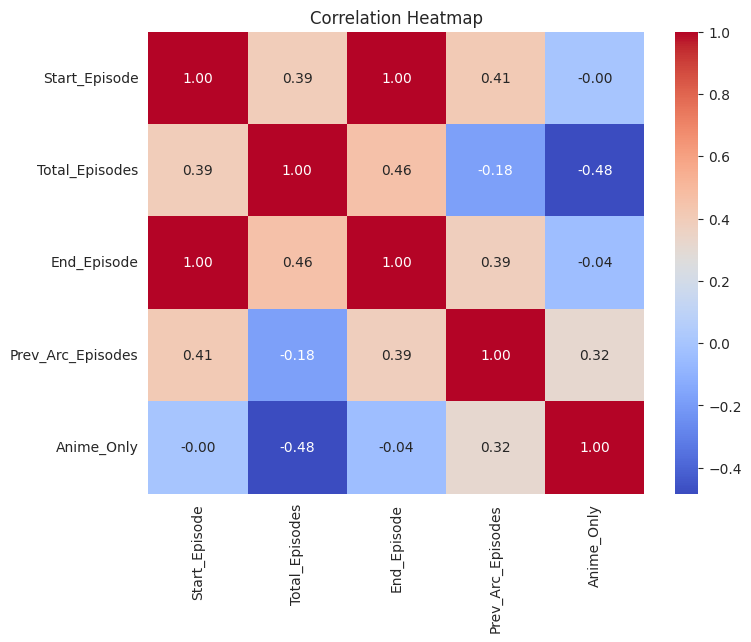

Root Node Gini Index: 0.455
Root Node Entropy: 0.9341
  Criterion  Train_Acc  Test_Acc  Precision  Recall   F1  Depth  Leaves
0      gini        1.0    0.8182     0.6667     1.0  0.8      4       6
1   entropy        1.0    0.8182     0.6667     1.0  0.8      4       6
gini 5-Fold CV Accuracy: 0.8436 +/- 0.0785
entropy 5-Fold CV Accuracy: 0.8436 +/- 0.0785


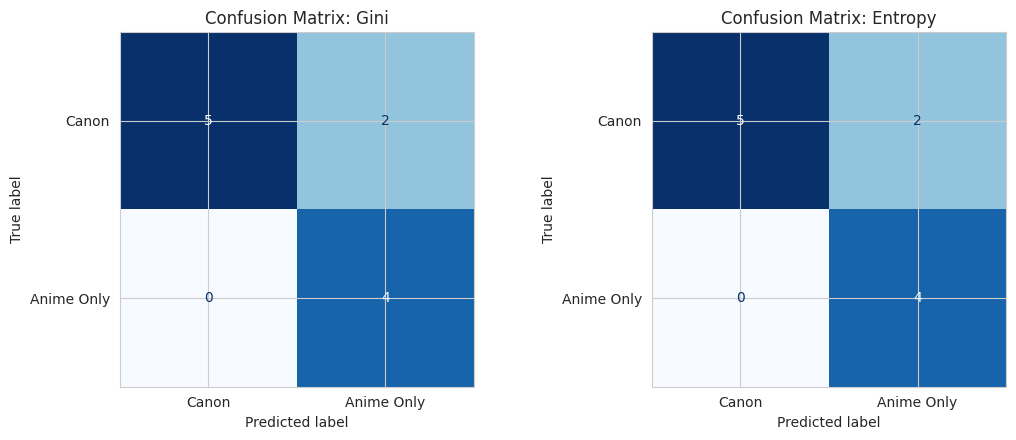

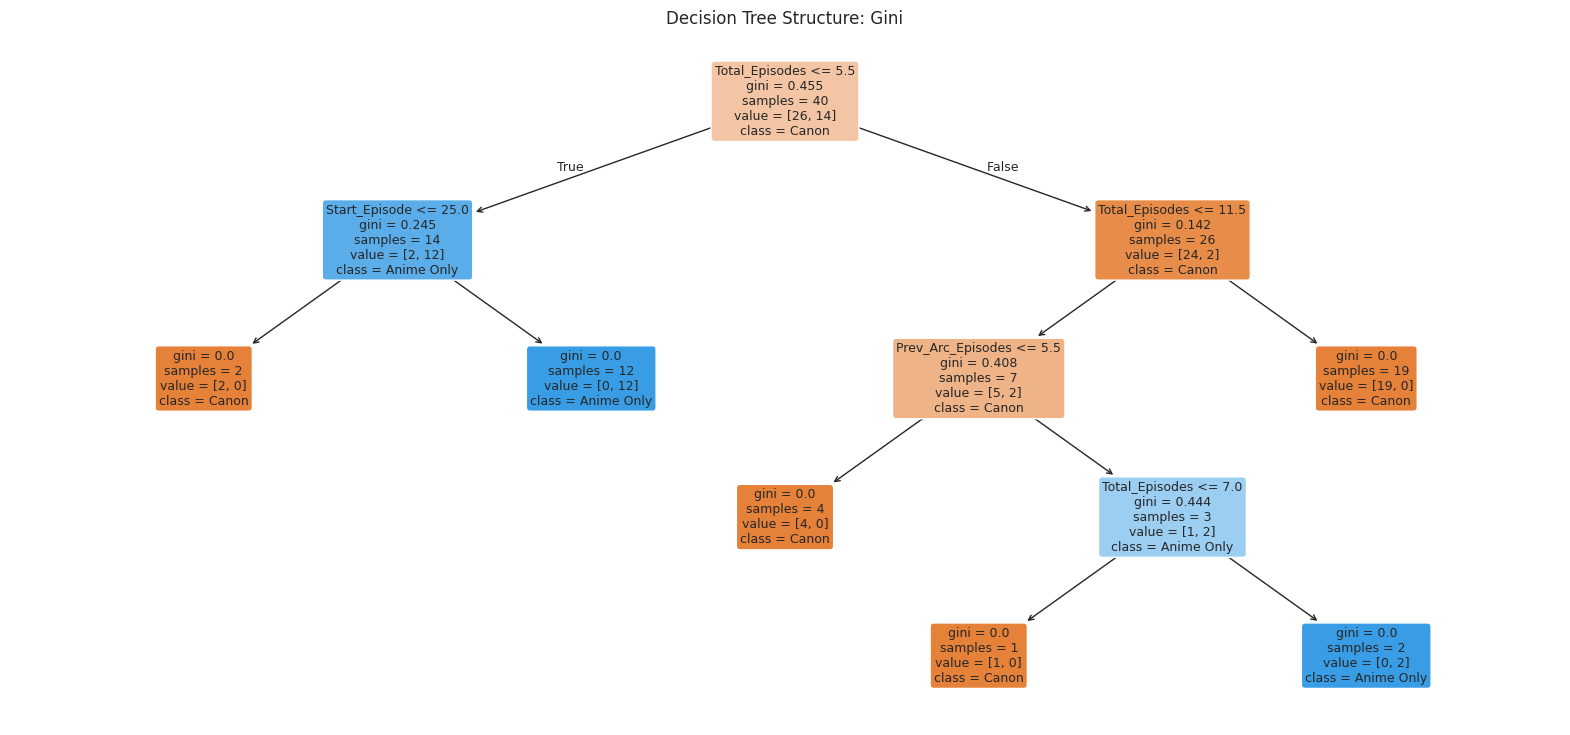

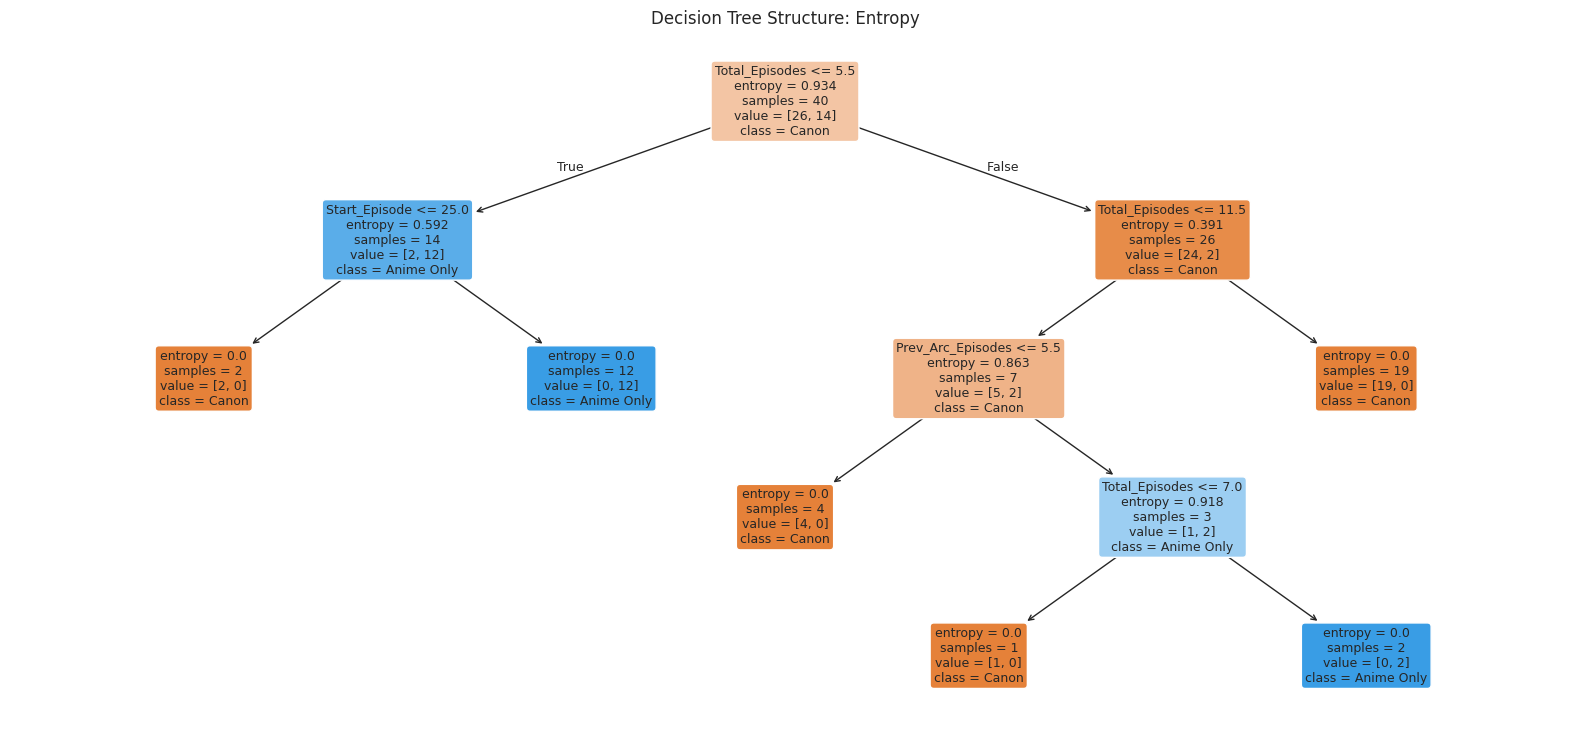

Number of candidate alphas: 3
Best CCP Alpha (CV on train): 0.08571
    alpha  train_acc  test_acc  cv_acc  leaves  depth
0  0.0000       1.00    0.8182     0.9       6      4
1  0.0308       0.95    0.7273     0.9       3      2
2  0.0857       0.90    0.7273     0.9       2      1


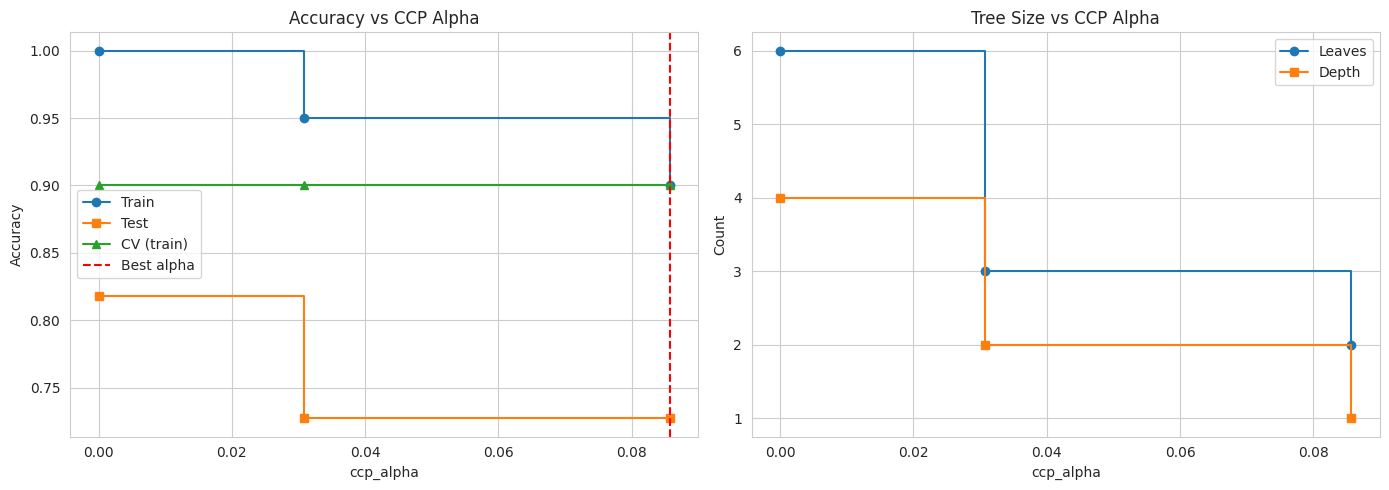

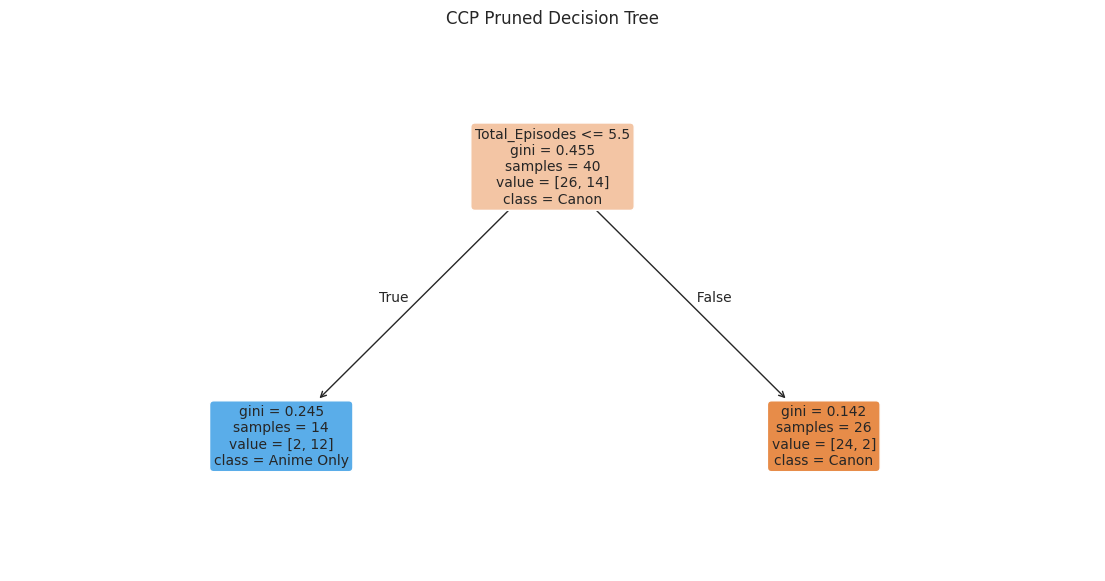

Best max_depth (CV on train): 1
   max_depth  train_acc  test_acc  cv_acc
0          1      0.900    0.7273     0.9
1          2      0.950    0.7273     0.9
2          3      0.975    0.8182     0.9
3          4      1.000    0.8182     0.9
4          5      1.000    0.8182     0.9
5          6      1.000    0.8182     0.9
6          7      1.000    0.8182     0.9
7          8      1.000    0.8182     0.9
8          9      1.000    0.8182     0.9
9         10      1.000    0.8182     0.9


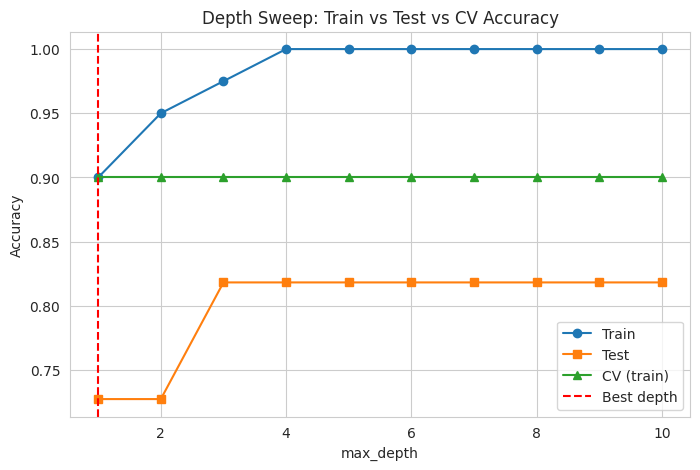

              Model  Accuracy  Precision  Recall      F1  Depth  Leaves
0     Unpruned Gini    0.8182     0.6667    1.00  0.8000      4       6
1  Unpruned Entropy    0.8182     0.6667    1.00  0.8000      4       6
2        CCP Pruned    0.7273     0.6000    0.75  0.6667      1       2
3        Best Depth    0.7273     0.6000    0.75  0.6667      1       2
              precision    recall  f1-score   support

       Canon       0.83      0.71      0.77         7
  Anime Only       0.60      0.75      0.67         4

    accuracy                           0.73        11
   macro avg       0.72      0.73      0.72        11
weighted avg       0.75      0.73      0.73        11



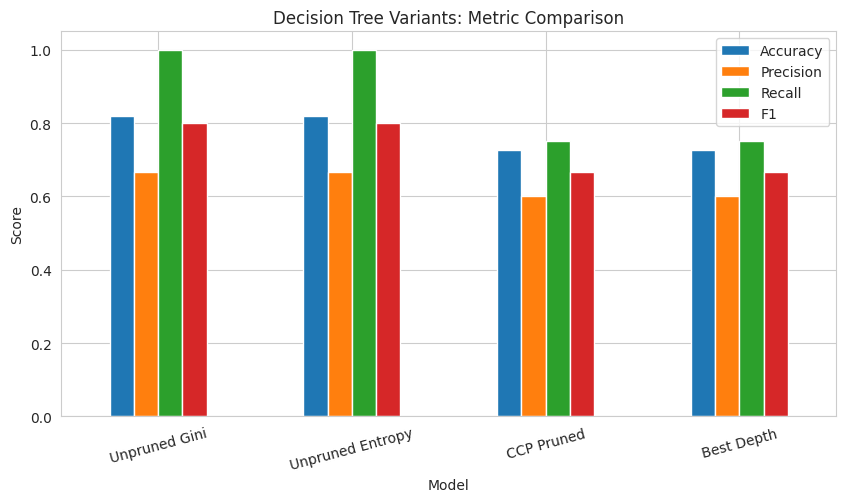

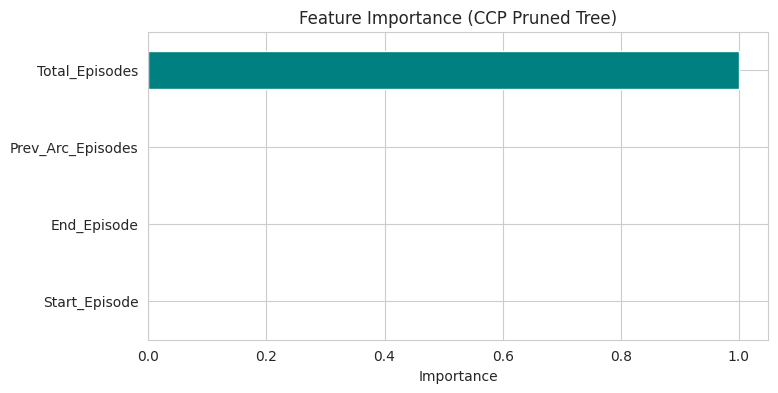

Total_Episodes       1.0
Start_Episode        0.0
End_Episode          0.0
Prev_Arc_Episodes    0.0
dtype: float64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
!pip -q install -U fg-data-profiling

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
from google.colab import files
from data_profiling import ProfileReport
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

PATH = "/content/OnePieceArcs.csv"
print("File found:", os.path.exists(PATH))

df = pd.read_csv(PATH)

print("Shape:", df.shape)
print(df.head())
print(df.tail())
print(df.columns.tolist())
print(df.dtypes)
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
print(df.describe())
print(df.sample(5, random_state=42))

df = df.rename(columns={
    "Start onChapter": "Start_Chapter",
    "TotalChapters": "Total_Chapters",
    "TotalPages": "Total_Pages",
    "Manga%": "Manga_Pct",
    "Start onEpisode": "Start_Episode",
    "TotalEpisodes": "Total_Episodes",
    "TotalMinutes(avg 24)": "Total_Minutes",
    "Anime%": "Anime_Pct"
})

for col in ["Manga_Pct", "Anime_Pct"]:
    df[col] = df[col].str.rstrip("%").astype(float)

df["Anime_Only"] = (df["Total_Chapters"] == 0).astype(int)
df["Label"] = df["Anime_Only"].map({0: "Canon", 1: "Anime Only"})
df["End_Episode"] = df["Start_Episode"] + df["Total_Episodes"] - 1
df["Prev_Arc_Episodes"] = df["Total_Episodes"].shift(1).fillna(0)

FEATURES = ["Start_Episode", "Total_Episodes", "End_Episode", "Prev_Arc_Episodes"]
CLASS_NAMES = ["Canon", "Anime Only"]

X = df[FEATURES]
y = df["Anime_Only"]

print(df[["Arc", "Total_Chapters", "Total_Episodes", "Anime_Only", "Label"]].head(10))
print(df["Label"].value_counts())
print(df["Label"].value_counts(normalize=True).round(3))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train class balance:", y_train.value_counts().to_dict())
print("Test class balance:", y_test.value_counts().to_dict())

pdf = PdfPages("Exp8_EDA_Report.pdf")

def save():
    pdf.savefig(plt.gcf(), bbox_inches="tight")
    plt.show()

profile = ProfileReport(df, title="One Piece Arcs EDA - Exp 8 Decision Tree", explorative=True, progress_bar=False)
profile.to_file("Exp8_Profile_Report.html")

plt.figure(figsize=(6, 4))
sns.countplot(x="Label", data=df, order=CLASS_NAMES, palette="Set2")
plt.title("Target Distribution: Canon vs Anime Only Arcs")
plt.xlabel("Arc Type")
plt.ylabel("Number of Arcs")
save()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["Total_Episodes"], bins=15, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Total Episodes per Arc")
sns.histplot(df["Start_Episode"], bins=15, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Distribution of Start Episode")
plt.tight_layout()
save()

plt.figure(figsize=(7, 4))
sns.boxplot(x="Label", y="Total_Episodes", data=df, order=CLASS_NAMES, palette="Set2")
plt.title("Arc Length by Arc Type")
save()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Start_Episode", y="Total_Episodes", hue="Label", hue_order=CLASS_NAMES, s=80, palette="Set1")
plt.title("Start Episode vs Total Episodes")
save()

plt.figure(figsize=(8, 6))
sns.heatmap(df[FEATURES + ["Anime_Only"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
save()

p = y_train.value_counts(normalize=True)
root_gini = 1 - (p ** 2).sum()
root_entropy = -(p * np.log2(p)).sum()
print("Root Node Gini Index:", round(root_gini, 4))
print("Root Node Entropy:", round(root_entropy, 4))

models = {}
rows = []
for criterion in ["gini", "entropy"]:
    m = DecisionTreeClassifier(criterion=criterion, random_state=42).fit(X_train, y_train)
    pred = m.predict(X_test)
    models[criterion] = m
    rows.append({
        "Criterion": criterion,
        "Train_Acc": m.score(X_train, y_train),
        "Test_Acc": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "Depth": m.get_depth(),
        "Leaves": m.get_n_leaves()
    })

criterion_results = pd.DataFrame(rows).round(4)
print(criterion_results)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for criterion in ["gini", "entropy"]:
    scores = cross_val_score(DecisionTreeClassifier(criterion=criterion, random_state=42), X, y, cv=cv)
    print(criterion, "5-Fold CV Accuracy: %.4f +/- %.4f" % (scores.mean(), scores.std()))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, criterion in zip(axes, ["gini", "entropy"]):
    ConfusionMatrixDisplay.from_estimator(models[criterion], X_test, y_test, display_labels=CLASS_NAMES, cmap="Blues", ax=ax, colorbar=False)
    ax.set_title("Confusion Matrix: " + criterion.capitalize())
plt.tight_layout()
save()

for criterion in ["gini", "entropy"]:
    plt.figure(figsize=(20, 9))
    plot_tree(models[criterion], feature_names=FEATURES, class_names=CLASS_NAMES, filled=True, rounded=True, fontsize=9)
    plt.title("Decision Tree Structure: " + criterion.capitalize())
    save()

path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
alphas = np.unique(path.ccp_alphas[:-1])

pruned_models = [DecisionTreeClassifier(random_state=42, ccp_alpha=a).fit(X_train, y_train) for a in alphas]
train_acc = [m.score(X_train, y_train) for m in pruned_models]
test_acc = [m.score(X_test, y_test) for m in pruned_models]
leaves = [m.get_n_leaves() for m in pruned_models]
depths = [m.get_depth() for m in pruned_models]
cv_acc = [cross_val_score(DecisionTreeClassifier(random_state=42, ccp_alpha=a), X_train, y_train, cv=cv).mean() for a in alphas]

best_alpha = alphas[np.where(np.isclose(cv_acc, max(cv_acc)))[0][-1]]
print("Number of candidate alphas:", len(alphas))
print("Best CCP Alpha (CV on train):", round(best_alpha, 5))

ccp_table = pd.DataFrame({"alpha": alphas, "train_acc": train_acc, "test_acc": test_acc, "cv_acc": cv_acc, "leaves": leaves, "depth": depths}).round(4)
print(ccp_table)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(alphas, train_acc, marker="o", drawstyle="steps-post", label="Train")
axes[0].plot(alphas, test_acc, marker="s", drawstyle="steps-post", label="Test")
axes[0].plot(alphas, cv_acc, marker="^", drawstyle="steps-post", label="CV (train)")
axes[0].axvline(best_alpha, color="red", linestyle="--", label="Best alpha")
axes[0].set_xlabel("ccp_alpha")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy vs CCP Alpha")
axes[0].legend()
axes[1].plot(alphas, leaves, marker="o", drawstyle="steps-post", label="Leaves")
axes[1].plot(alphas, depths, marker="s", drawstyle="steps-post", label="Depth")
axes[1].set_xlabel("ccp_alpha")
axes[1].set_ylabel("Count")
axes[1].set_title("Tree Size vs CCP Alpha")
axes[1].legend()
plt.tight_layout()
save()

ccp_tree = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha).fit(X_train, y_train)
plt.figure(figsize=(14, 7))
plot_tree(ccp_tree, feature_names=FEATURES, class_names=CLASS_NAMES, filled=True, rounded=True, fontsize=10)
plt.title("CCP Pruned Decision Tree")
save()

depth_range = range(1, 11)
d_train, d_test, d_cv = [], [], []
for d in depth_range:
    m = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    d_train.append(m.score(X_train, y_train))
    d_test.append(m.score(X_test, y_test))
    d_cv.append(cross_val_score(DecisionTreeClassifier(max_depth=d, random_state=42), X_train, y_train, cv=cv).mean())

best_depth = list(depth_range)[int(np.argmax(d_cv))]
print("Best max_depth (CV on train):", best_depth)
print(pd.DataFrame({"max_depth": list(depth_range), "train_acc": d_train, "test_acc": d_test, "cv_acc": d_cv}).round(4))

plt.figure(figsize=(8, 5))
plt.plot(depth_range, d_train, marker="o", label="Train")
plt.plot(depth_range, d_test, marker="s", label="Test")
plt.plot(depth_range, d_cv, marker="^", label="CV (train)")
plt.axvline(best_depth, color="red", linestyle="--", label="Best depth")
plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Depth Sweep: Train vs Test vs CV Accuracy")
plt.legend()
save()

depth_tree = DecisionTreeClassifier(max_depth=best_depth, random_state=42).fit(X_train, y_train)

final_models = {
    "Unpruned Gini": models["gini"],
    "Unpruned Entropy": models["entropy"],
    "CCP Pruned": ccp_tree,
    "Best Depth": depth_tree
}

rows = []
for name, m in final_models.items():
    pred = m.predict(X_test)
    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "Depth": m.get_depth(),
        "Leaves": m.get_n_leaves()
    })
comparison = pd.DataFrame(rows).round(4)
print(comparison)
print(classification_report(y_test, ccp_tree.predict(X_test), target_names=CLASS_NAMES, zero_division=0))

comparison.set_index("Model")[["Accuracy", "Precision", "Recall", "F1"]].plot(kind="bar", figsize=(10, 5), rot=15)
plt.title("Decision Tree Variants: Metric Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
save()

importance = pd.Series(ccp_tree.feature_importances_, index=FEATURES).sort_values()
plt.figure(figsize=(8, 4))
importance.plot(kind="barh", color="teal")
plt.title("Feature Importance (CCP Pruned Tree)")
plt.xlabel("Importance")
save()
print(importance.sort_values(ascending=False).round(4))

pdf.close()
files.download("Exp8_Profile_Report.html")
files.download("Exp8_EDA_Report.pdf")